# Session Purchase Analysis

Business question:
What proportion of observed sessions contain at least one purchase?

Metric:
Purchasing sessions / total sessions.

A session uses our project rule of a new session after an inactivity
gap of at least 30 minutes.

This analysis describes historical observed behavior.
It does not establish why visitors purchased or left.

In [15]:
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import snowflake.connector

from scipy.stats import norm
from IPython.display import display


connection = snowflake.connector.connect(
    account="NXAUBQR-GS92621",
    user="VISHALMURLIKUMAR",
    password=getpass("Snowflake password: "),
    authenticator="username_password_mfa",
    role="SYSADMIN",
    warehouse="RETAILROCKET_WH",
    database="RETAILROCKET",
    schema="ANALYTICS",
)


def query_dataframe(sql):
    """Execute a query and return its results as a DataFrame."""
    with connection.cursor() as cursor:
        cursor.execute(sql)
        columns = [column[0].lower() for column in cursor.description]
        return pd.DataFrame(cursor.fetchall(), columns=columns)


print("Connected to Snowflake.")

Connected to Snowflake.


In [16]:
summary = query_dataframe("""
    SELECT
        COUNT(*) AS total_sessions,
        SUM(CASE WHEN has_purchase THEN 1 ELSE 0 END)
            AS purchasing_sessions,
        COUNT(DISTINCT visitor_id) AS total_visitors
    FROM RETAILROCKET.ANALYTICS.FCT_SESSIONS
""")

for column in summary.columns:
    summary[column] = pd.to_numeric(summary[column])

summary["session_purchase_rate_pct"] = (
    100
    * summary["purchasing_sessions"]
    / summary["total_sessions"]
)

display(summary.round(4))

,total_sessions,purchasing_sessions,total_visitors,session_purchase_rate_pct
0,1761676,14297,1407580,0.8116


In [17]:
moments = query_dataframe("""
    WITH visitor_sessions AS (
        SELECT
            visitor_id,
            COUNT(*) AS session_count,
            SUM(CASE WHEN has_purchase THEN 1 ELSE 0 END)
                AS purchasing_session_count
        FROM RETAILROCKET.ANALYTICS.FCT_SESSIONS
        GROUP BY visitor_id
    )

    SELECT
        COUNT(*) AS visitor_count,
        SUM(session_count) AS total_sessions,
        SUM(purchasing_session_count) AS purchasing_sessions,
        SUM(purchasing_session_count * purchasing_session_count)
            AS sum_purchase_squared,
        SUM(purchasing_session_count * session_count)
            AS sum_purchase_times_sessions,
        SUM(session_count * session_count) AS sum_sessions_squared
    FROM visitor_sessions
""")

values = moments.iloc[0].astype(float)

visitor_count = values["visitor_count"]
total_sessions = values["total_sessions"]
purchasing_sessions = values["purchasing_sessions"]

assert visitor_count > 1
assert total_sessions > 0

purchase_rate = purchasing_sessions / total_sessions

residual_sum_squares = (
    values["sum_purchase_squared"]
    - 2 * purchase_rate * values["sum_purchase_times_sessions"]
    + purchase_rate**2 * values["sum_sessions_squared"]
)

cluster_variance = (
    visitor_count / (visitor_count - 1)
    * max(residual_sum_squares, 0.0)
    / total_sessions**2
)

standard_error = np.sqrt(cluster_variance)
critical_value = norm.ppf(0.975)

lower_bound = max(
    0.0, purchase_rate - critical_value * standard_error
)
upper_bound = min(
    1.0, purchase_rate + critical_value * standard_error
)

confidence_summary = pd.DataFrame({
    "session_purchase_rate_pct": [purchase_rate * 100],
    "lower_95_pct": [lower_bound * 100],
    "upper_95_pct": [upper_bound * 100],
    "visitor_clusters": [int(visitor_count)],
})

display(confidence_summary.round(4))

,session_purchase_rate_pct,lower_95_pct,upper_95_pct,visitor_clusters
0,0.8116,0.7777,0.8454,1407580


In [18]:
daily = query_dataframe("""
    WITH daily_sessions AS (
        SELECT
            session_date,
            COUNT(*) AS total_sessions,
            SUM(CASE WHEN has_purchase THEN 1 ELSE 0 END)
                AS purchasing_sessions
        FROM RETAILROCKET.ANALYTICS.FCT_SESSIONS
        GROUP BY session_date
    )

    SELECT
        dates.date_day AS session_date,
        COALESCE(sessions.total_sessions, 0) AS total_sessions,
        COALESCE(sessions.purchasing_sessions, 0)
            AS purchasing_sessions
    FROM RETAILROCKET.ANALYTICS.DIM_DATES AS dates
    LEFT JOIN daily_sessions AS sessions
        ON dates.date_day = sessions.session_date
    ORDER BY dates.date_day
""")

daily["session_date"] = pd.to_datetime(daily["session_date"])

for column in ["total_sessions", "purchasing_sessions"]:
    daily[column] = pd.to_numeric(daily[column])

assert daily["session_date"].is_unique
assert (
    daily["total_sessions"].sum()
    == summary.loc[0, "total_sessions"]
)
assert (
    daily["purchasing_sessions"].sum()
    == summary.loc[0, "purchasing_sessions"]
)

daily["daily_purchase_rate_pct"] = (
    100
    * daily["purchasing_sessions"]
    / daily["total_sessions"].replace(0, np.nan)
)

# The first and last UTC observation dates are partial days.
daily["is_boundary_date"] = (
    daily["session_date"].eq(daily["session_date"].min())
    | daily["session_date"].eq(daily["session_date"].max())
)

trend = daily.loc[~daily["is_boundary_date"]].copy()

rolling_purchases = trend["purchasing_sessions"].rolling(
    window=7, min_periods=7
).sum()

rolling_sessions = trend["total_sessions"].rolling(
    window=7, min_periods=7
).sum()

trend["seven_day_purchase_rate_pct"] = (
    100
    * rolling_purchases
    / rolling_sessions.replace(0, np.nan)
)

print("Daily totals reconcile with the overall summary.")
display(trend.head(10).round(4))

Daily totals reconcile with the overall summary.


C:\Users\visha\AppData\Local\Temp\ipykernel_30800\991372857.py:67: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(trend.head(10).round(4))


,session_date,total_sessions,purchasing_sessions,daily_purchase_rate_pct,is_boundary_date,seven_day_purchase_rate_pct
1,2015-05-04,11778,108,0.9170,False,NaN
2,2015-05-05,14093,166,1.1779,False,NaN
3,2015-05-06,14772,169,1.1441,False,NaN
4,2015-05-07,14112,125,0.8858,False,NaN
5,2015-05-08,11938,88,0.7371,False,NaN
6,2015-05-09,8112,46,0.5671,False,NaN
7,2015-05-10,7886,49,0.6214,False,0.9082
8,2015-05-11,10116,61,0.6030,False,0.8688
9,2015-05-12,14031,132,0.9408,False,0.8275
10,2015-05-13,14470,144,0.9952,False,0.7996


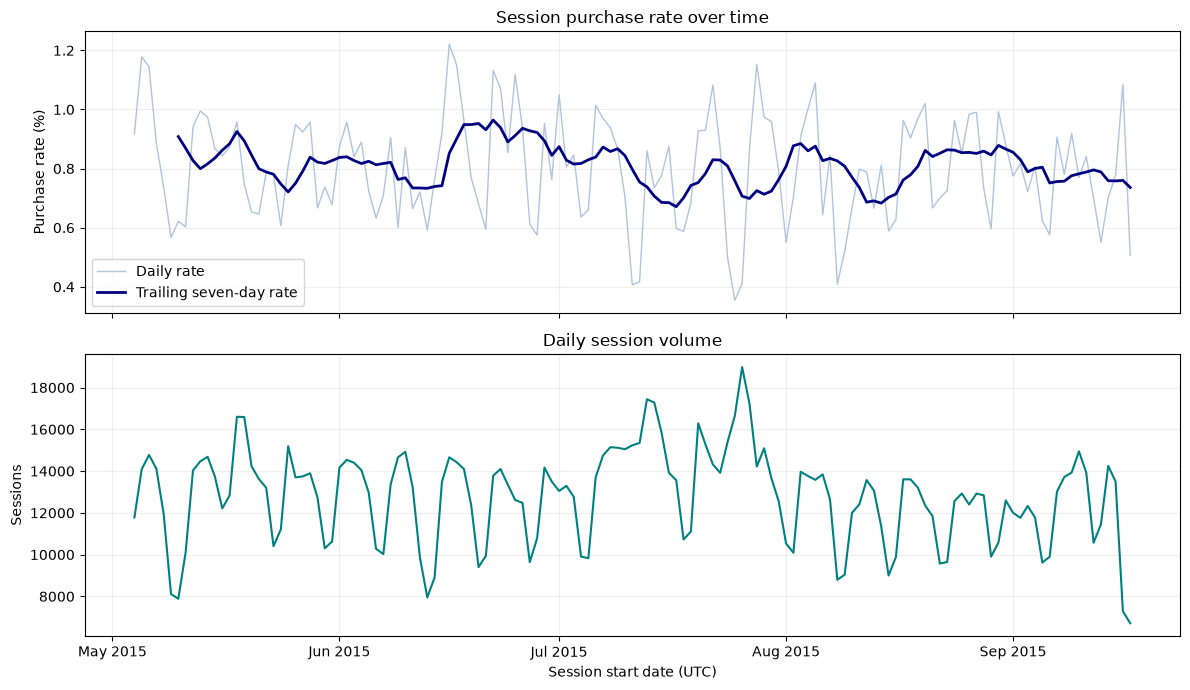

In [19]:
fig, axes = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True
)

axes[0].plot(
    trend["session_date"],
    trend["daily_purchase_rate_pct"],
    color="lightsteelblue",
    linewidth=1,
    label="Daily rate",
)

axes[0].plot(
    trend["session_date"],
    trend["seven_day_purchase_rate_pct"],
    color="navy",
    linewidth=2,
    label="Trailing seven-day rate",
)

axes[0].set_title("Session purchase rate over time")
axes[0].set_ylabel("Purchase rate (%)")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(
    trend["session_date"],
    trend["total_sessions"],
    color="teal",
)

axes[1].set_title("Daily session volume")
axes[1].set_ylabel("Sessions")
axes[1].set_xlabel("Session start date (UTC)")
axes[1].grid(alpha=0.2)

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

fig.tight_layout()
plt.show()

In [20]:
monthly = (
    trend.assign(
        month=trend["session_date"].dt.to_period("M")
    )
    .groupby("month", as_index=False)
    .agg(
        observed_days=("session_date", "size"),
        total_sessions=("total_sessions", "sum"),
        purchasing_sessions=("purchasing_sessions", "sum"),
    )
)

monthly["calendar_days"] = monthly["month"].dt.days_in_month

monthly["is_complete_month"] = (
    monthly["observed_days"] == monthly["calendar_days"]
)

monthly["session_purchase_rate_pct"] = (
    100
    * monthly["purchasing_sessions"]
    / monthly["total_sessions"].replace(0, np.nan)
)

display(monthly.round(4))

C:\Users\visha\AppData\Local\Temp\ipykernel_30800\2916849572.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(monthly.round(4))


,month,observed_days,total_sessions,purchasing_sessions,calendar_days,is_complete_month,session_purchase_rate_pct
0,2015-05,28,360828,3028,31,False,0.8392
1,2015-06,30,376108,3213,30,True,0.8543
2,2015-07,31,446613,3482,31,True,0.7796
3,2015-08,31,368074,2975,31,True,0.8083
4,2015-09,17,200694,1530,30,False,0.7624


In [21]:
complete_months = monthly.loc[
    monthly["is_complete_month"]
].copy()

complete_months["rate_change_percentage_points"] = (
    complete_months["session_purchase_rate_pct"].diff()
)

complete_months["session_volume_change_pct"] = (
    complete_months["total_sessions"].pct_change(
        fill_method=None
    ) * 100
)

display(complete_months.round(4))

if not complete_months.empty:
    highest_rate = complete_months.loc[
        complete_months["session_purchase_rate_pct"].idxmax()
    ]

    print(
        f"Highest observed complete-month purchase rate: "
        f"{highest_rate['month']} "
        f"({highest_rate['session_purchase_rate_pct']:.4f}%)."
    )

C:\Users\visha\AppData\Local\Temp\ipykernel_30800\671230616.py:15: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(complete_months.round(4))


,month,observed_days,total_sessions,purchasing_sessions,calendar_days,is_complete_month,session_purchase_rate_pct,rate_change_percentage_points,session_volume_change_pct
1,2015-06,30,376108,3213,30,True,0.8543,NaN,NaN
2,2015-07,31,446613,3482,31,True,0.7796,-0.0746,18.7459
3,2015-08,31,368074,2975,31,True,0.8083,0.0286,-17.5855


Highest observed complete-month purchase rate: 2015-06 (0.8543%).


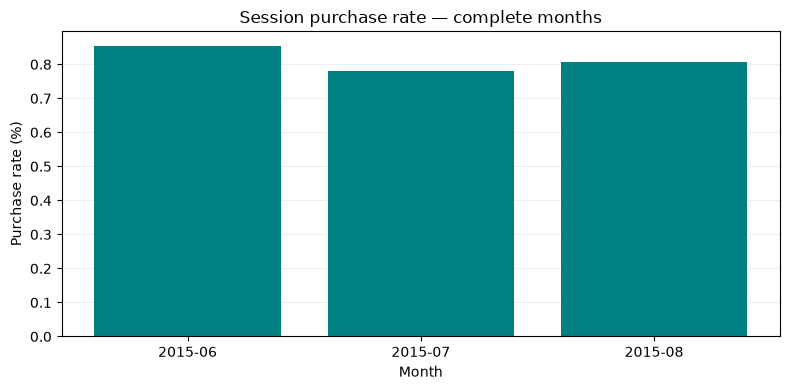

In [22]:
if not complete_months.empty:
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.bar(
        complete_months["month"].astype(str),
        complete_months["session_purchase_rate_pct"],
        color="teal",
    )

    ax.set_title("Session purchase rate — complete months")
    ax.set_xlabel("Month")
    ax.set_ylabel("Purchase rate (%)")
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

    fig.tight_layout()
    plt.show()

In [23]:
connection.close()
print("Connection closed.")

Connection closed.
